In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Load the datasets
customers=pd.read_csv("/content/customers.csv")
products=pd.read_csv("/content/products.csv")
categories=pd.read_csv("/content/categories.csv")
orders=pd.read_csv("/content/orders.csv")
order_items=pd.read_csv("/content/order_items.csv")
payments=pd.read_csv("/content/payments.csv")
shipping=pd.read_csv("/content/shipping.csv")




In [9]:
# Total Customers
total_customers = customers['customer_id'].nunique()
print("Total Customers:", total_customers)
# Total Orders
total_orders = orders['order_id'].nunique()
print("Total Orders:", total_orders)
# Total Revenue
total_revenue = orders['total_amount'].sum()
print("Total Revenue:", total_revenue,)
# Total Categories
total_categories = categories['category_id'].nunique()
print("Total Categories:", total_categories)
# Total Products
total_products = products['product_id'].nunique()
print("Total Products:", total_products)
# Average Order value
average_order_value = orders['total_amount'].mean()
print("Average Order Value:", average_order_value,)

Total Customers: 5000
Total Orders: 8000
Total Revenue: 302699038.49
Total Categories: 10
Total Products: 1000
Average Order Value: 37837.37981125


In [38]:
#  Top 10 Selling Products
top_products = (
    order_items
    .merge(products,on='product_id')
    .groupby('product_name')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

product_name
Jeans          1758
Sofa           1669
Rice           1584
Shampoo        1562
Pan            1526
Toy Car        1487
Sugar          1449
Cricket Bat    1446
Sunglasses     1408
Smart TV       1388
Name: quantity, dtype: int64


In [16]:
# Top Categories by Sales
category_sales = (
    order_items
    .merge(products,on='product_id')
    .merge(categories,on='category_id')
)

top_categories = (
    category_sales
    .groupby('category_name')
    .apply(lambda x:(x['quantity']*x['unit_price']).sum())
    .sort_values(ascending=False)
)

print(top_categories)

category_name
Grocery        1.279913e+08
Beauty         1.249518e+08
Fashion        1.229171e+08
Sports         1.210405e+08
Books          1.207635e+08
Toys           1.194218e+08
Home           1.183859e+08
Electronics    1.177247e+08
Kitchen        1.155926e+08
Accessories    1.106582e+08
dtype: float64


/tmp/ipykernel_9577/2538451879.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x:(x['quantity']*x['unit_price']).sum())


In [17]:
# Monthly Sales Trend
orders['order_date'] = pd.to_datetime(orders['order_date'])

monthly_sales = (
    orders
    .groupby(orders['order_date'].dt.to_period('M'))
    ['total_amount']
    .sum()
)

print(monthly_sales)

order_date
2024-01    13227620.49
2024-02    12046075.79
2024-03    11315907.71
2024-04    12096420.35
2024-05    13097265.79
2024-06    12253531.15
2024-07    13841480.00
2024-08    14014507.54
2024-09    11773057.58
2024-10    12996614.28
2024-11    12655654.16
2024-12    12539114.71
2025-01    12313971.86
2025-02    12309328.56
2025-03    13175114.16
2025-04    11461158.00
2025-05    13066096.09
2025-06    13154762.07
2025-07    13421508.71
2025-08    13732232.36
2025-09    12594678.34
2025-10    11290183.02
2025-11    11800717.39
2025-12    12522038.38
Freq: M, Name: total_amount, dtype: float64


In [18]:
# Top 5 Customers by Revenue
top_customers = (
    orders
    .groupby('customer_id')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(top_customers)

customer_id
4226    317226.43
2569    316867.16
3948    310292.38
4730    299006.79
537     295223.25
Name: total_amount, dtype: float64


In [19]:
# Revenue by State
state_revenue = (
    orders
    .merge(customers,on='customer_id')
    .groupby('state')['total_amount']
    .sum()
    .sort_values(ascending=False)
)

print(state_revenue)

state
Karnataka      54001596.47
Telangana      53025851.98
Delhi          49735569.29
West Bengal    49198259.50
Maharashtra    49067653.55
Tamil Nadu     47670107.70
Name: total_amount, dtype: float64


In [20]:
# Revenue by City
city_revenue = (
    orders
    .merge(customers,on='customer_id')
    .groupby('city')['total_amount']
    .sum()
    .sort_values(ascending=False)
)

print(city_revenue)

city
Bengaluru    54001596.47
Hyderabad    53025851.98
Delhi        49735569.29
Kolkata      49198259.50
Pune         49067653.55
Chennai      47670107.70
Name: total_amount, dtype: float64


In [21]:
# Payment Method by Analysis
payment_analysis = (
    payments
    .groupby('payment_method')
    .size()
    .sort_values(ascending=False)
)

print(payment_analysis)

payment_method
UPI            1641
Net Banking    1616
Debit Card     1606
Credit Card    1606
COD            1531
dtype: int64


In [22]:
# Order State Analysis
status_analysis = (
    orders
    .groupby('order_status')
    .size()
)

print(status_analysis)

order_status
Cancelled    1977
Delivered    1972
Pending      2027
Shipped      2024
dtype: int64


In [23]:
# Revenue by Gender
gender_revenue = (
    orders
    .merge(customers,on='customer_id')
    .groupby('gender')['total_amount']
    .sum()
)

print(gender_revenue)

gender
Female    1.505060e+08
Male      1.521931e+08
Name: total_amount, dtype: float64


In [24]:
# Top brands by Revenue
brand_revenue = (
    order_items
    .merge(products,on='product_id')
)

brand_revenue = (
    brand_revenue
    .groupby('brand')
    .apply(lambda x:(x['quantity']*x['unit_price']).sum())
    .sort_values(ascending=False)
)

print(brand_revenue)


brand
Prestige         49062283.68
Cosco            48219331.54
Aashirvaad       47713969.76
HarperCollins    47680019.23
Loreal           44970772.80
Wildcraft        44619276.68
IKEA             43780479.70
Lego             43199078.80
Maybelline       42818110.09
Fortune          42587574.11
Funskool         38542049.82
Nilkamal         38110211.22
H&M              37910927.86
Tata             37689798.55
Mattel           37680650.55
Pigeon           37469238.43
Lakme            37162940.39
Penguin          36890804.17
Nivia            36496267.33
HomeCentre       36495231.72
SG               36324854.21
Oxford           36192702.79
Dell             35857762.37
Fastrack         33821882.78
Titan            32217052.54
Apple            30365258.46
Puma             30090747.30
Butterfly        29061080.83
Zara             28946638.00
Samsung          28194325.21
Levis            25968818.23
Sony             23307338.59
dtype: float64


/tmp/ipykernel_9577/1893166636.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x:(x['quantity']*x['unit_price']).sum())


In [25]:
# Monthly Order Count
monthly_orders = (
    orders
    .groupby(orders['order_date'].dt.to_period('M'))
    ['order_id']
    .count()
)

print(monthly_orders)

order_date
2024-01    342
2024-02    307
2024-03    308
2024-04    311
2024-05    338
2024-06    326
2024-07    360
2024-08    374
2024-09    315
2024-10    337
2024-11    317
2024-12    341
2025-01    340
2025-02    321
2025-03    331
2025-04    317
2025-05    345
2025-06    343
2025-07    347
2025-08    365
2025-09    336
2025-10    311
2025-11    332
2025-12    336
Freq: M, Name: order_id, dtype: int64


In [26]:
# Most used Courier Service
courier_analysis = (
    shipping
    .groupby('courier_name')
    .size()
    .sort_values(ascending=False)
)

print(courier_analysis)

courier_name
Ekart        2034
DTDC         1999
Delhivery    1984
Blue Dart    1983
dtype: int64


In [27]:
# Customer Lifetime Value
clv = (
    orders
    .groupby('customer_id')['total_amount']
    .sum()
    .sort_values(ascending=False)
)

print(clv.head())

customer_id
4226    317226.43
2569    316867.16
3948    310292.38
4730    299006.79
537     295223.25
Name: total_amount, dtype: float64


In [28]:
# Top 20 Customers
top20 = (
    orders
    .groupby('customer_id')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print(top20)

customer_id
4226    317226.43
2569    316867.16
3948    310292.38
4730    299006.79
537     295223.25
2418    292323.16
653     291990.95
2574    286144.51
1867    284687.37
2038    278947.17
1287    276683.47
4455    276599.67
1996    274470.68
228     272043.38
2712    268332.66
3623    266156.16
43      263369.27
4177    263253.00
1344    263091.67
3277    261195.04
Name: total_amount, dtype: float64


In [30]:
# Repeat Customers
repeat_customers = (
    orders
    .groupby('customer_id')
    .size()
)

repeat_customers = repeat_customers[repeat_customers > 1]

print("Repeat Customers:", len(repeat_customers))

Repeat Customers: 2364


In [31]:
# New Customers
new_customers = (
    orders
    .groupby('customer_id')
    .size()
)

new_customers = new_customers[new_customers == 1]

print("New Customers:", len(new_customers))

New Customers: 1621


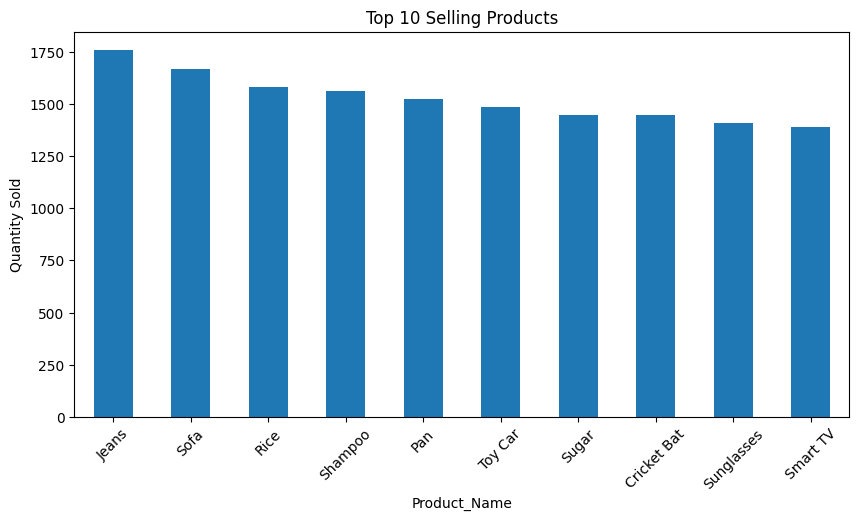

In [39]:
# Top 10 Products Chart
top_products.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Selling Products')
plt.xlabel('Product_Name')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()

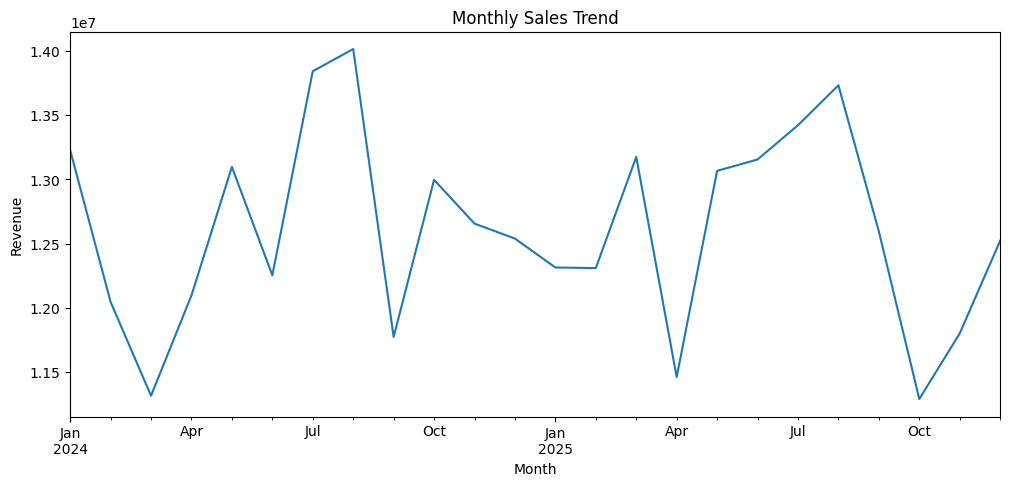

In [34]:
# Monthly Revenue Trend Chart
monthly_sales.plot(
    figsize=(12,5)
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()